# Airline Passenger Satisfaction Analysis

CEO and Board Management Report

A professional decision-ready report built from `passenger_survey_balanced.csv`. The notebook moves from executive conclusions to statistical validation so leadership can see both the management story and the analytical evidence behind it.

[Open the dark mode dashboard](../dashboard/index.html)

**Created by Hieu Nguyen**

## 1. Executive Framing

This notebook is structured for senior leadership review. It prioritizes business implications first, then provides the statistical appendix needed to defend the recommendations.

Board-level questions answered:

1. Where is passenger satisfaction strongest and weakest across the journey?
2. Which experience gaps are large enough to deserve management attention?
3. Which signals remain reliable after statistical testing and multiple-testing correction?
4. Which operational priorities should be funded, monitored, or escalated?

In [1]:
from pathlib import Path
from textwrap import wrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")



def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan, dtype=float)
    valid_mask = ~np.isnan(p_values)
    valid_p = p_values[valid_mask]
    if valid_p.size == 0:
        return adjusted
    order = np.argsort(valid_p)
    ranked = valid_p[order]
    n = valid_p.size
    q_values = ranked * n / np.arange(1, n + 1)
    q_values = np.minimum.accumulate(q_values[::-1])[::-1]
    q_values = np.clip(q_values, 0, 1)
    valid_adjusted = np.empty_like(valid_p)
    valid_adjusted[order] = q_values
    adjusted[valid_mask] = valid_adjusted
    return adjusted


def cohen_d(group_a, group_b):
    group_a = np.asarray(group_a.dropna(), dtype=float)
    group_b = np.asarray(group_b.dropna(), dtype=float)
    if len(group_a) < 2 or len(group_b) < 2:
        return np.nan
    variance_a = group_a.var(ddof=1)
    variance_b = group_b.var(ddof=1)
    pooled = ((len(group_a) - 1) * variance_a + (len(group_b) - 1) * variance_b) / (len(group_a) + len(group_b) - 2)
    if pooled <= 0:
        return np.nan
    return (group_a.mean() - group_b.mean()) / np.sqrt(pooled)


def cramers_v(contingency_table):
    chi2, _, _, _ = stats.chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    rows, cols = contingency_table.shape
    if n <= 1 or rows < 2 or cols < 2:
        return np.nan
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((cols - 1) * (rows - 1)) / (n - 1))
    rows_corr = rows - ((rows - 1) ** 2) / (n - 1)
    cols_corr = cols - ((cols - 1) ** 2) / (n - 1)
    denominator = min(cols_corr - 1, rows_corr - 1)
    if denominator <= 0:
        return np.nan
    return np.sqrt(phi2_corr / denominator)


def wilson_interval(successes, total, z=1.96):
    if total == 0:
        return np.nan, np.nan
    p_hat = successes / total
    denominator = 1 + z**2 / total
    centre = p_hat + z**2 / (2 * total)
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * total)) / total)
    return (centre - margin) / denominator, (centre + margin) / denominator

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "passenger_survey_balanced.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "passenger_survey_balanced.csv"

plt.rcParams.update({
    "figure.figsize": (12, 7),
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "font.family": "DejaVu Sans",
    "axes.facecolor": "#F8FAFC",
    "figure.facecolor": "#FFFFFF",
    "axes.edgecolor": "#CBD5E1",
    "axes.labelcolor": "#1E293B",
    "axes.titlecolor": "#0F172A",
    "xtick.color": "#334155",
    "ytick.color": "#334155",
    "grid.color": "#E2E8F0",
    "grid.linewidth": 0.8,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "navy": "#14213D",
    "gold": "#FCA311",
    "teal": "#2A9D8F",
    "coral": "#E76F51",
    "violet": "#6D597A",
    "mint": "#8AB17D",
    "slate": "#475569",
    "light": "#E2E8F0",
}


def clean_label(label: str) -> str:
    return label.replace("_", " ").replace("is applicable", "").strip().title()


def wrap_label(label: str, width: int = 24) -> str:
    return "\n".join(wrap(clean_label(label), width=width))


def percent_axis(ax):
    ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")


def annotate_bars(ax, fmt="{:.1%}", color="#0F172A", x_offset=0):
    for patch in ax.patches:
        width = patch.get_width()
        height = patch.get_height()
        if np.isnan(width) or np.isnan(height):
            continue
        if width >= height:
            ax.text(
                patch.get_x() + width + x_offset,
                patch.get_y() + height / 2,
                fmt.format(width),
                va="center",
                ha="left",
                fontsize=9,
                color=color,
            )
        else:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_y() + height,
                fmt.format(height),
                va="bottom",
                ha="center",
                fontsize=9,
                color=color,
            )

In [2]:
df = pd.read_csv(DATA_PATH)

applicability_cols = [col for col in df.columns if col.endswith("_is_applicable")]
numeric_cols = df.select_dtypes(include="number").columns.tolist()

rating_cols = []
for col in numeric_cols:
    if col == "liked" or col in applicability_cols:
        continue
    values = df[col].dropna()
    if values.empty:
        continue
    within_rating_scale = values.between(1, 5).mean() >= 0.95
    has_rating_cardinality = values.nunique() <= 5
    if within_rating_scale and has_rating_cardinality:
        rating_cols.append(col)

overview = pd.DataFrame({
    "metric": [
        "Rows",
        "Columns",
        "Rating attributes detected",
        "Applicability flags",
        "Target positive rate",
        "Missing values",
    ],
    "value": [
        f"{df.shape[0]:,}",
        f"{df.shape[1]:,}",
        f"{len(rating_cols):,}",
        f"{len(applicability_cols):,}",
        f"{df['liked'].mean():.1%}",
        f"{df.isna().sum().sum():,}",
    ],
})

display(Markdown("### Dataset Snapshot"))
display(overview)

display(Markdown("### First Rows"))
display(df.head())

### Dataset Snapshot

,metric,value
0,Rows,"57,514"
1,Columns,145
2,Rating attributes detected,60
3,Applicability flags,59
4,Target positive rate,50.0%
5,Missing values,"3,323,783"


### First Rows

,process,month,flight_type,connection,ticket_purchased_by,ticket_purchase_channel,transport_to_airport,has_disability,uses_assistive_device,requested_special_assistance,disembarkation_method_used,disembarkation_method_rating,used_parking,curbside_dropoff_ease,transport_options_to_airport,checkin_method,checkin_process,checkin_queue_wait_time,checkin_queue_organization,self_service_kiosk_quantity,checkin_counter_quantity,staff_courtesy,checkin_service_time,ticket_purchase_process,airline_service,security_screening_process,security_queue_wait_time,security_queue_organization,security_staff_service,immigration_control,immigration_queue_wait_time,immigration_queue_organization,immigration_staff_service,service_window_quantity,customs_control,customs_queue_wait_time,customs_queue_organization,customs_staff_service,food_beverage_outlets,food_beverage_outlet_quantity,food_beverage_quality_variety,food_beverage_price_quality,retail_outlets,retail_outlet_quantity,retail_quality_variety,retail_price_quality,parking,parking_facility_quality,parking_space_availability_ease,parking_terminal_access_ease,parking_value_for_money,location_and_movement,signage,flight_information_display_availability,terminal_accessibility,boarding_lounge_comfort,thermal_comfort,acoustic_comfort,seat_availability,reserved_seat_availability,...,liked,disembarkation_method_rating_is_applicable,curbside_dropoff_ease_is_applicable,transport_options_to_airport_is_applicable,checkin_process_is_applicable,checkin_queue_wait_time_is_applicable,checkin_queue_organization_is_applicable,self_service_kiosk_quantity_is_applicable,checkin_counter_quantity_is_applicable,staff_courtesy_is_applicable,checkin_service_time_is_applicable,ticket_purchase_process_is_applicable,airline_service_is_applicable,security_screening_process_is_applicable,security_queue_wait_time_is_applicable,security_queue_organization_is_applicable,security_staff_service_is_applicable,immigration_queue_wait_time_is_applicable,immigration_queue_organization_is_applicable,immigration_staff_service_is_applicable,service_window_quantity_is_applicable,customs_control_is_applicable,customs_queue_wait_time_is_applicable,customs_queue_organization_is_applicable,customs_staff_service_is_applicable,food_beverage_outlets_is_applicable,food_beverage_outlet_quantity_is_applicable,food_beverage_quality_variety_is_applicable,food_beverage_price_quality_is_applicable,retail_outlets_is_applicable,retail_outlet_quantity_is_applicable,retail_quality_variety_is_applicable,retail_price_quality_is_applicable,parking_is_applicable,parking_facility_quality_is_applicable,parking_space_availability_ease_is_applicable,parking_terminal_access_ease_is_applicable,parking_value_for_money_is_applicable,signage_is_applicable,flight_information_display_availability_is_applicable,terminal_accessibility_is_applicable,boarding_lounge_comfort_is_applicable,thermal_comfort_is_applicable,acoustic_comfort_is_applicable,seat_availability_is_applicable,reserved_seat_availability_is_applicable,power_outlet_availability_is_applicable,airport_internet_is_applicable,internet_connection_speed_is_applicable,network_access_ease_is_applicable,restrooms_is_applicable,restroom_quantity_is_applicable,restroom_cleanliness_is_applicable,restroom_maintenance_is_applicable,baggage_claim_process_is_applicable,baggage_carousel_identification_ease_is_applicable,baggage_claim_time_is_applicable,baggage_integrity_is_applicable,arrival_lead_time_is_applicable,connection_wait_time_is_applicable
0,Boarding,October,Domestic,Boarded at the airport,By the passenger,Airline website/app,Ride from someone,No,Not applicable,Not applicable,Not applicable,NaN,NaN,3.00,3.00,Counter,4.00,NaN,NaN,NaN,NaN,NaN,NaN,4.00,NaN,3.00,2.00,2.00,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,3.00,3.00,3.00,3.00,NaN,...,1,0,1,1,1,0,0,0,0,0,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0

## 2. CEO & Board Executive Scorecard

This section turns the analysis into a management agenda. The scorecard keeps the focus on decision quality: scale, satisfaction baseline, process gap, largest journey theme gap, and top improvement lever.

In [3]:
board_process = df.groupby("process")["liked"].agg(records="size", liked_rate="mean").sort_values("liked_rate", ascending=False)

board_rating_means = df.groupby("liked")[rating_cols].mean().T.rename(columns={0: "Disliked", 1: "Liked"})
board_rating_means["Gap"] = board_rating_means["Liked"] - board_rating_means["Disliked"]
board_rating_means["Priority Score"] = board_rating_means["Gap"] * (5 - board_rating_means["Disliked"])

board_theme_map = {
    "Access & Parking": [
        "curbside_dropoff_ease", "transport_options_to_airport", "parking", "parking_facility_quality",
        "parking_space_availability_ease", "parking_terminal_access_ease", "parking_value_for_money",
    ],
    "Check-in & Airline": [
        "checkin_process", "checkin_queue_wait_time", "checkin_queue_organization", "self_service_kiosk_quantity",
        "checkin_counter_quantity", "staff_courtesy", "checkin_service_time", "ticket_purchase_process", "airline_service",
    ],
    "Security & Border": [
        "security_screening_process", "security_queue_wait_time", "security_queue_organization", "security_staff_service",
        "immigration_control", "immigration_queue_wait_time", "immigration_queue_organization", "immigration_staff_service",
        "customs_control", "customs_queue_wait_time", "customs_queue_organization", "customs_staff_service", "service_window_quantity",
    ],
    "Commercial Offer": [
        "food_beverage_outlets", "food_beverage_outlet_quantity", "food_beverage_quality_variety",
        "food_beverage_price_quality", "retail_outlets", "retail_outlet_quantity", "retail_quality_variety", "retail_price_quality",
    ],
    "Wayfinding & Comfort": [
        "location_and_movement", "signage", "flight_information_display_availability", "terminal_accessibility",
        "boarding_lounge_comfort", "thermal_comfort", "acoustic_comfort", "seat_availability", "reserved_seat_availability",
        "power_outlet_availability",
    ],
    "Digital Experience": ["airport_internet", "internet_connection_speed", "network_access_ease"],
    "Cleanliness & Restrooms": [
        "restrooms", "restroom_quantity", "restroom_cleanliness", "restroom_maintenance", "overall_airport_cleanliness",
    ],
    "Baggage & Arrival": [
        "disembarkation_method_rating", "baggage_claim_process", "baggage_carousel_identification_ease",
        "baggage_claim_time", "baggage_integrity",
    ],
}

board_theme_scores = pd.DataFrame(index=df.index)
for theme, columns in board_theme_map.items():
    available = [col for col in columns if col in df.columns]
    board_theme_scores[theme] = df[available].mean(axis=1, skipna=True)
board_theme_scores["liked"] = df["liked"]
board_theme_summary = board_theme_scores.groupby("liked").mean().T.rename(columns={0: "Disliked", 1: "Liked"})
board_theme_summary["Gap"] = board_theme_summary["Liked"] - board_theme_summary["Disliked"]

top_priority = board_rating_means.sort_values("Priority Score", ascending=False).iloc[0]
top_theme = board_theme_summary.sort_values("Gap", ascending=False).iloc[0]
boarding_rate = board_process.loc["Boarding", "liked_rate"]
disembarkation_rate = board_process.loc["Disembarkation", "liked_rate"]

scorecard = pd.DataFrame({
    "Executive KPI": [
        "Survey records",
        "Satisfaction baseline",
        "Boarding liked rate",
        "Disembarkation liked rate",
        "Process gap",
        "Largest theme gap",
        "Top management priority",
    ],
    "Result": [
        f"{len(df):,}",
        f"{df['liked'].mean():.1%}",
        f"{boarding_rate:.1%}",
        f"{disembarkation_rate:.1%}",
        f"{(disembarkation_rate - boarding_rate) * 100:.1f} percentage points",
        f"{clean_label(top_theme.name)} ({top_theme['Gap']:+.2f} rating points)",
        f"{clean_label(top_priority.name)} (priority score {top_priority['Priority Score']:.2f})",
    ],
    "Board Interpretation": [
        "Large enough base for stable pattern detection.",
        "Balanced target is ideal for comparing liked vs. disliked experiences.",
        "Boarding is the weaker journey process and should be monitored closely.",
        "Arrival/disembarkation performs slightly better in this survey base.",
        "A modest but visible process gap that can compound across passenger volume.",
        "This journey theme most clearly separates liked from disliked experiences.",
        "This attribute combines a large satisfaction gap with a weak disliked-group baseline.",
    ],
})

management_agenda = (
    board_rating_means.sort_values("Priority Score", ascending=False)
    .head(6)
    .rename(index=clean_label)
    [["Disliked", "Liked", "Gap", "Priority Score"]]
)

display(Markdown("### Board Scorecard"))
display(scorecard)
display(Markdown("### Immediate Management Agenda"))
display(management_agenda)

### Board Scorecard

,Executive KPI,Result,Board Interpretation
0,Survey records,"57,514",Large enough base for stable pattern detection.
1,Satisfaction baseline,50.0%,Balanced target is ideal for comparing liked v...
2,Boarding liked rate,48.9%,Boarding is the weaker journey process and sho...
3,Disembarkation liked rate,51.5%,Arrival/disembarkation performs slightly bette...
4,Process gap,2.6 percentage points,A modest but visible process gap that can comp...
5,Largest theme gap,Commercial Offer (+1.01 rating points),This journey theme most clearly separates like...
6,Top management priority,Boarding Lounge Comfort (priority score 2.31),This attribute combines a large satisfaction g...


### Immediate Management Agenda

liked,Disliked,Liked,Gap,Priority Score
Boarding Lounge Comfort,3.04,4.22,1.18,2.31
Power Outlet Availability,2.89,3.97,1.08,2.29
Reserved Seat Availability,2.88,3.94,1.06,2.25
Parking,3.06,4.21,1.15,2.22
Parking Facility Quality,2.64,3.51,0.87,2.05
Baggage Claim Process,3.25,4.40,1.15,2.02


## 3. Satisfaction At A Glance

The dataset is balanced, so the target split is useful for comparing experience patterns without one class dominating the analysis.

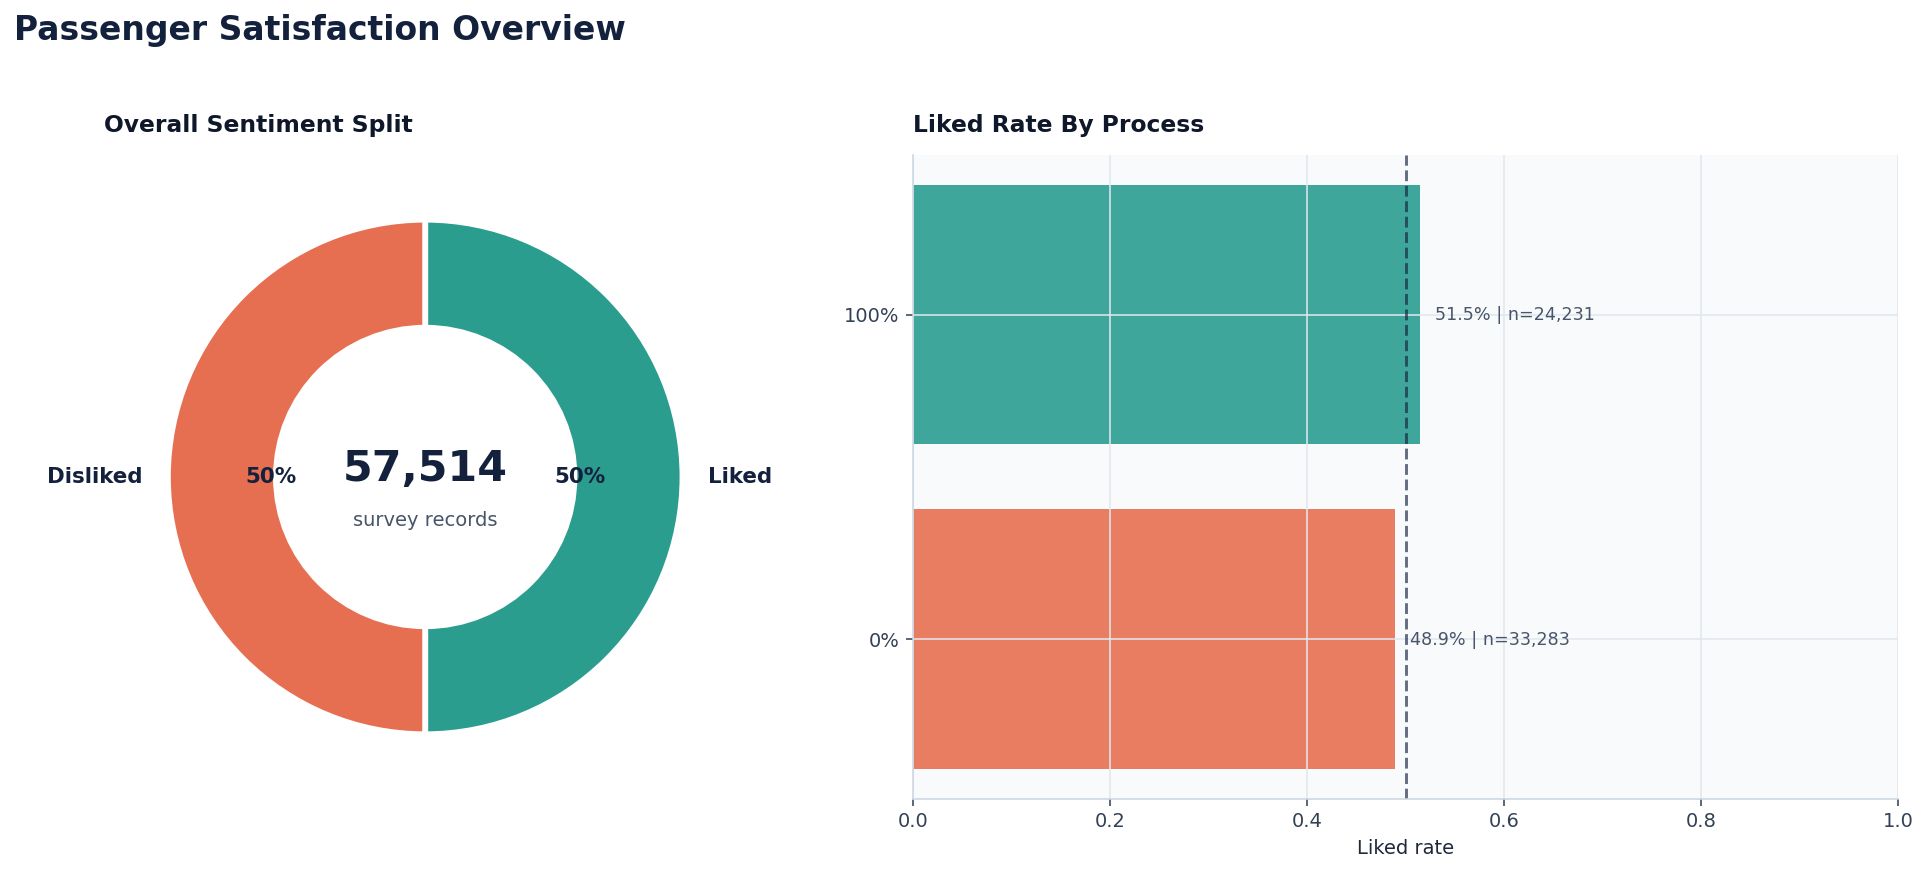

In [4]:
liked_counts = df["liked"].map({1: "Liked", 0: "Disliked"}).value_counts().reindex(["Liked", "Disliked"])
process_mix = df.groupby("process")["liked"].agg(records="size", liked_rate="mean").sort_values("records", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [0.9, 1.2]})

ax1.pie(
    liked_counts,
    labels=liked_counts.index,
    startangle=90,
    counterclock=False,
    colors=[COLORS["teal"], COLORS["coral"]],
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 3},
    autopct=lambda pct: f"{pct:.0f}%",
    textprops={"color": COLORS["navy"], "fontsize": 11, "weight": "bold"},
)
ax1.text(0, 0.03, f"{len(df):,}", ha="center", va="center", fontsize=22, weight="bold", color=COLORS["navy"])
ax1.text(0, -0.17, "survey records", ha="center", va="center", fontsize=10, color=COLORS["slate"])
ax1.set_title("Overall Sentiment Split", loc="left", weight="bold", pad=12)

bars = ax2.barh(
    [wrap_label(index, 22) for index in process_mix.index],
    process_mix["liked_rate"],
    color=[COLORS["teal"] if value >= 0.5 else COLORS["coral"] for value in process_mix["liked_rate"]],
    alpha=0.9,
)
ax2.axvline(0.5, color=COLORS["navy"], linewidth=1.5, linestyle="--", alpha=0.65)
ax2.set_xlim(0, 1)
ax2.set_xlabel("Liked rate")
ax2.set_title("Liked Rate By Process", loc="left", weight="bold", pad=12)
percent_axis(ax2)
for bar, records in zip(bars, process_mix["records"]):
    width = bar.get_width()
    ax2.text(width + 0.015, bar.get_y() + bar.get_height()/2, f"{width:.1%} | n={records:,}", va="center", fontsize=9, color=COLORS["slate"])

fig.suptitle("Passenger Satisfaction Overview", x=0.02, y=1.03, ha="left", fontsize=17, weight="bold", color=COLORS["navy"])
fig.tight_layout()
plt.show()

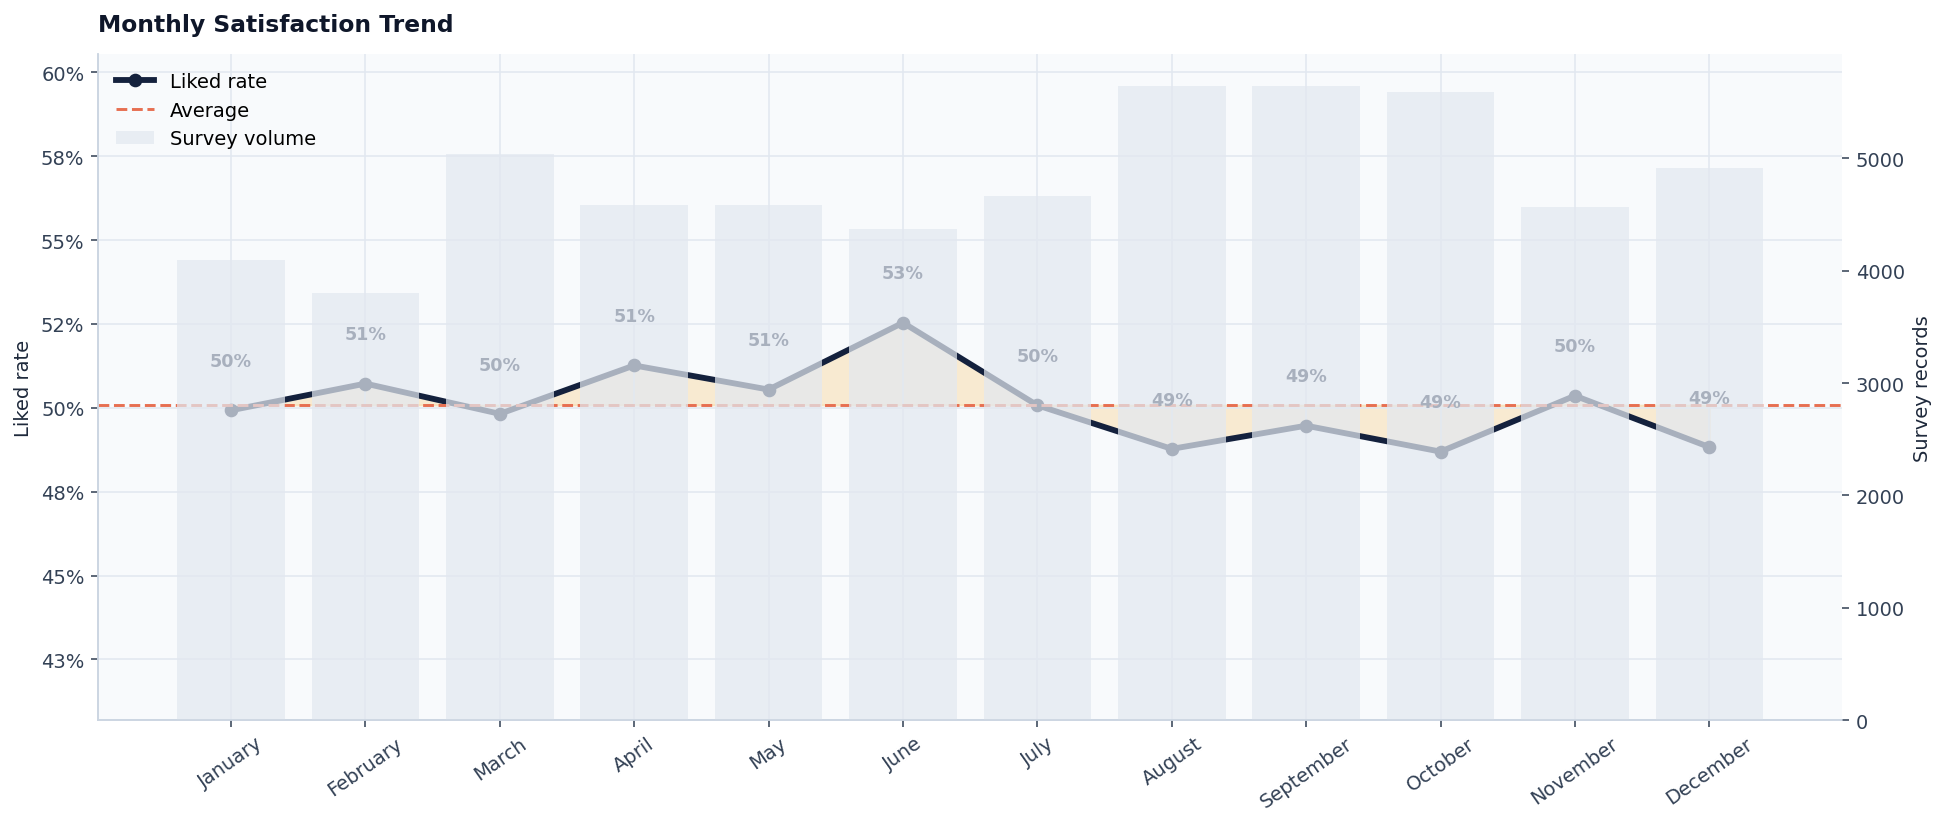

In [5]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
monthly = (
    df.assign(month=pd.Categorical(df["month"], categories=month_order, ordered=True))
      .groupby("month", observed=False)
      .agg(records=("liked", "size"), liked_rate=("liked", "mean"))
      .dropna(subset=["liked_rate"])
)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax2.bar(monthly.index.astype(str), monthly["records"], color=COLORS["light"], alpha=0.72, label="Survey volume")
ax1.plot(monthly.index.astype(str), monthly["liked_rate"], color=COLORS["navy"], marker="o", linewidth=3, label="Liked rate")
ax1.fill_between(np.arange(len(monthly)), monthly["liked_rate"], monthly["liked_rate"].mean(), color=COLORS["gold"], alpha=0.18)
ax1.axhline(monthly["liked_rate"].mean(), color=COLORS["coral"], linestyle="--", linewidth=1.5, label="Average")

for idx, value in enumerate(monthly["liked_rate"]):
    ax1.text(idx, value + 0.012, f"{value:.0%}", ha="center", va="bottom", fontsize=9, color=COLORS["navy"], weight="bold")

ax1.set_ylim(max(0, monthly["liked_rate"].min() - 0.08), min(1, monthly["liked_rate"].max() + 0.08))
ax1.set_ylabel("Liked rate")
ax2.set_ylabel("Survey records")
percent_axis(ax1)
ax1.set_title("Monthly Satisfaction Trend", loc="left", weight="bold", pad=12)
ax1.tick_params(axis="x", rotation=35)
ax1.grid(True, axis="y")
ax2.grid(False)

lines, labels = ax1.get_legend_handles_labels()
bars, bar_labels = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + bar_labels, loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

## 4. Journey Theme Scores

Survey items are grouped into journey themes so that individual ratings become easier to read as operational experience areas.

In [6]:
theme_map = {
    "Access & Parking": [
        "curbside_dropoff_ease", "transport_options_to_airport", "parking", "parking_facility_quality",
        "parking_space_availability_ease", "parking_terminal_access_ease", "parking_value_for_money",
    ],
    "Check-in & Airline": [
        "checkin_process", "checkin_queue_wait_time", "checkin_queue_organization", "self_service_kiosk_quantity",
        "checkin_counter_quantity", "staff_courtesy", "checkin_service_time", "ticket_purchase_process", "airline_service",
    ],
    "Security & Border": [
        "security_screening_process", "security_queue_wait_time", "security_queue_organization", "security_staff_service",
        "immigration_control", "immigration_queue_wait_time", "immigration_queue_organization", "immigration_staff_service",
        "customs_control", "customs_queue_wait_time", "customs_queue_organization", "customs_staff_service", "service_window_quantity",
    ],
    "Commercial Offer": [
        "food_beverage_outlets", "food_beverage_outlet_quantity", "food_beverage_quality_variety",
        "food_beverage_price_quality", "retail_outlets", "retail_outlet_quantity", "retail_quality_variety", "retail_price_quality",
    ],
    "Wayfinding & Comfort": [
        "location_and_movement", "signage", "flight_information_display_availability", "terminal_accessibility",
        "boarding_lounge_comfort", "thermal_comfort", "acoustic_comfort", "seat_availability", "reserved_seat_availability",
        "power_outlet_availability",
    ],
    "Digital Experience": ["airport_internet", "internet_connection_speed", "network_access_ease"],
    "Cleanliness & Restrooms": [
        "restrooms", "restroom_quantity", "restroom_cleanliness", "restroom_maintenance", "overall_airport_cleanliness",
    ],
    "Baggage & Arrival": [
        "disembarkation_method_rating", "baggage_claim_process", "baggage_carousel_identification_ease",
        "baggage_claim_time", "baggage_integrity",
    ],
}

theme_scores = pd.DataFrame(index=df.index)
theme_coverage = []
for theme, columns in theme_map.items():
    available = [col for col in columns if col in df.columns]
    theme_scores[theme] = df[available].mean(axis=1, skipna=True)
    theme_coverage.append({"theme": theme, "attributes": len(available), "response_coverage": theme_scores[theme].notna().mean()})

theme_scores["liked"] = df["liked"]
theme_summary = theme_scores.groupby("liked").mean().T.rename(columns={0: "Disliked", 1: "Liked"})
theme_summary["Gap"] = theme_summary["Liked"] - theme_summary["Disliked"]

display(pd.DataFrame(theme_coverage).sort_values("response_coverage", ascending=False))
display(theme_summary.sort_values("Gap", ascending=False))

,theme,attributes,response_coverage
4,Wayfinding & Comfort,10,1.00
6,Cleanliness & Restrooms,5,0.58
2,Security & Border,13,0.45
0,Access & Parking,7,0.39
1,Check-in & Airline,9,0.37
3,Commercial Offer,8,0.31
7,Baggage & Arrival,5,0.30
5,Digital Experience,3,0.14


liked,Disliked,Liked,Gap
Commercial Offer,3.23,4.24,1.01
Wayfinding & Comfort,3.40,4.35,0.95
Baggage & Arrival,3.53,4.46,0.93
Cleanliness & Restrooms,3.57,4.47,0.89
Access & Parking,3.59,4.33,0.74
Digital Experience,3.70,4.42,0.72
Check-in & Airline,3.97,4.50,0.52
Security & Border,4.07,4.58,0.51


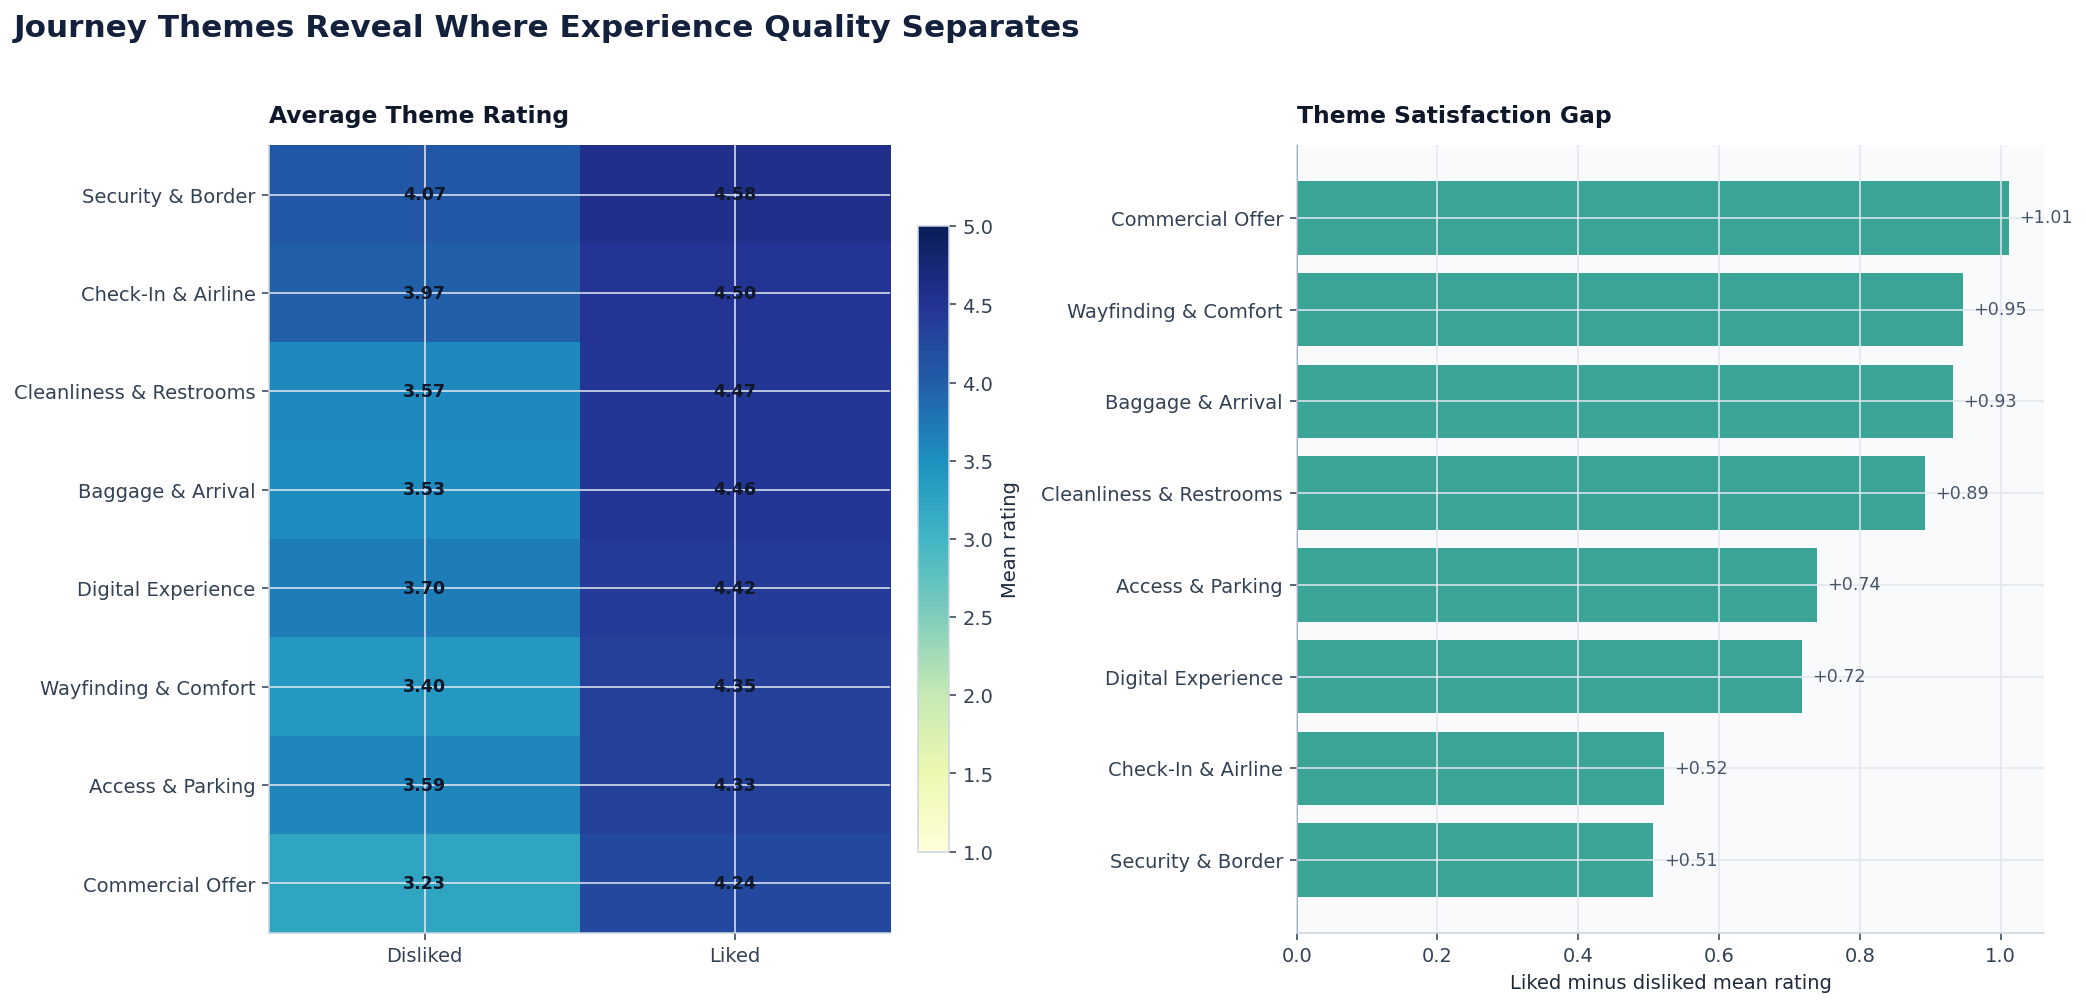

In [7]:
plot_data = theme_summary[["Disliked", "Liked"]].sort_values("Liked", ascending=False)
gap_data = theme_summary["Gap"].sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1, 1.1]})

image = ax1.imshow(plot_data, aspect="auto", cmap="YlGnBu", vmin=1, vmax=5)
ax1.set_xticks(range(plot_data.shape[1]), plot_data.columns)
ax1.set_yticks(range(plot_data.shape[0]), [wrap_label(label, 24) for label in plot_data.index])
ax1.set_title("Average Theme Rating", loc="left", weight="bold", pad=12)
for row in range(plot_data.shape[0]):
    for col in range(plot_data.shape[1]):
        ax1.text(col, row, f"{plot_data.iloc[row, col]:.2f}", ha="center", va="center", color="#0F172A", fontsize=9, weight="bold")
fig.colorbar(image, ax=ax1, fraction=0.046, pad=0.04, label="Mean rating")

colors = [COLORS["teal"] if value >= 0 else COLORS["coral"] for value in gap_data]
ax2.barh([wrap_label(label, 25) for label in gap_data.index], gap_data, color=colors, alpha=0.92)
ax2.axvline(0, color=COLORS["navy"], linewidth=1)
ax2.set_xlabel("Liked minus disliked mean rating")
ax2.set_title("Theme Satisfaction Gap", loc="left", weight="bold", pad=12)
for idx, value in enumerate(gap_data):
    ax2.text(value + (0.015 if value >= 0 else -0.015), idx, f"{value:+.2f}", va="center", ha="left" if value >= 0 else "right", fontsize=9, color=COLORS["slate"])

fig.suptitle("Journey Themes Reveal Where Experience Quality Separates", x=0.01, y=1.02, ha="left", fontsize=16, weight="bold", color=COLORS["navy"])
fig.tight_layout()
plt.show()

## 5. Service Attribute Drivers

The next view compares average ratings for liked and disliked records. A larger positive gap means the attribute is much stronger among liked trips than disliked trips.

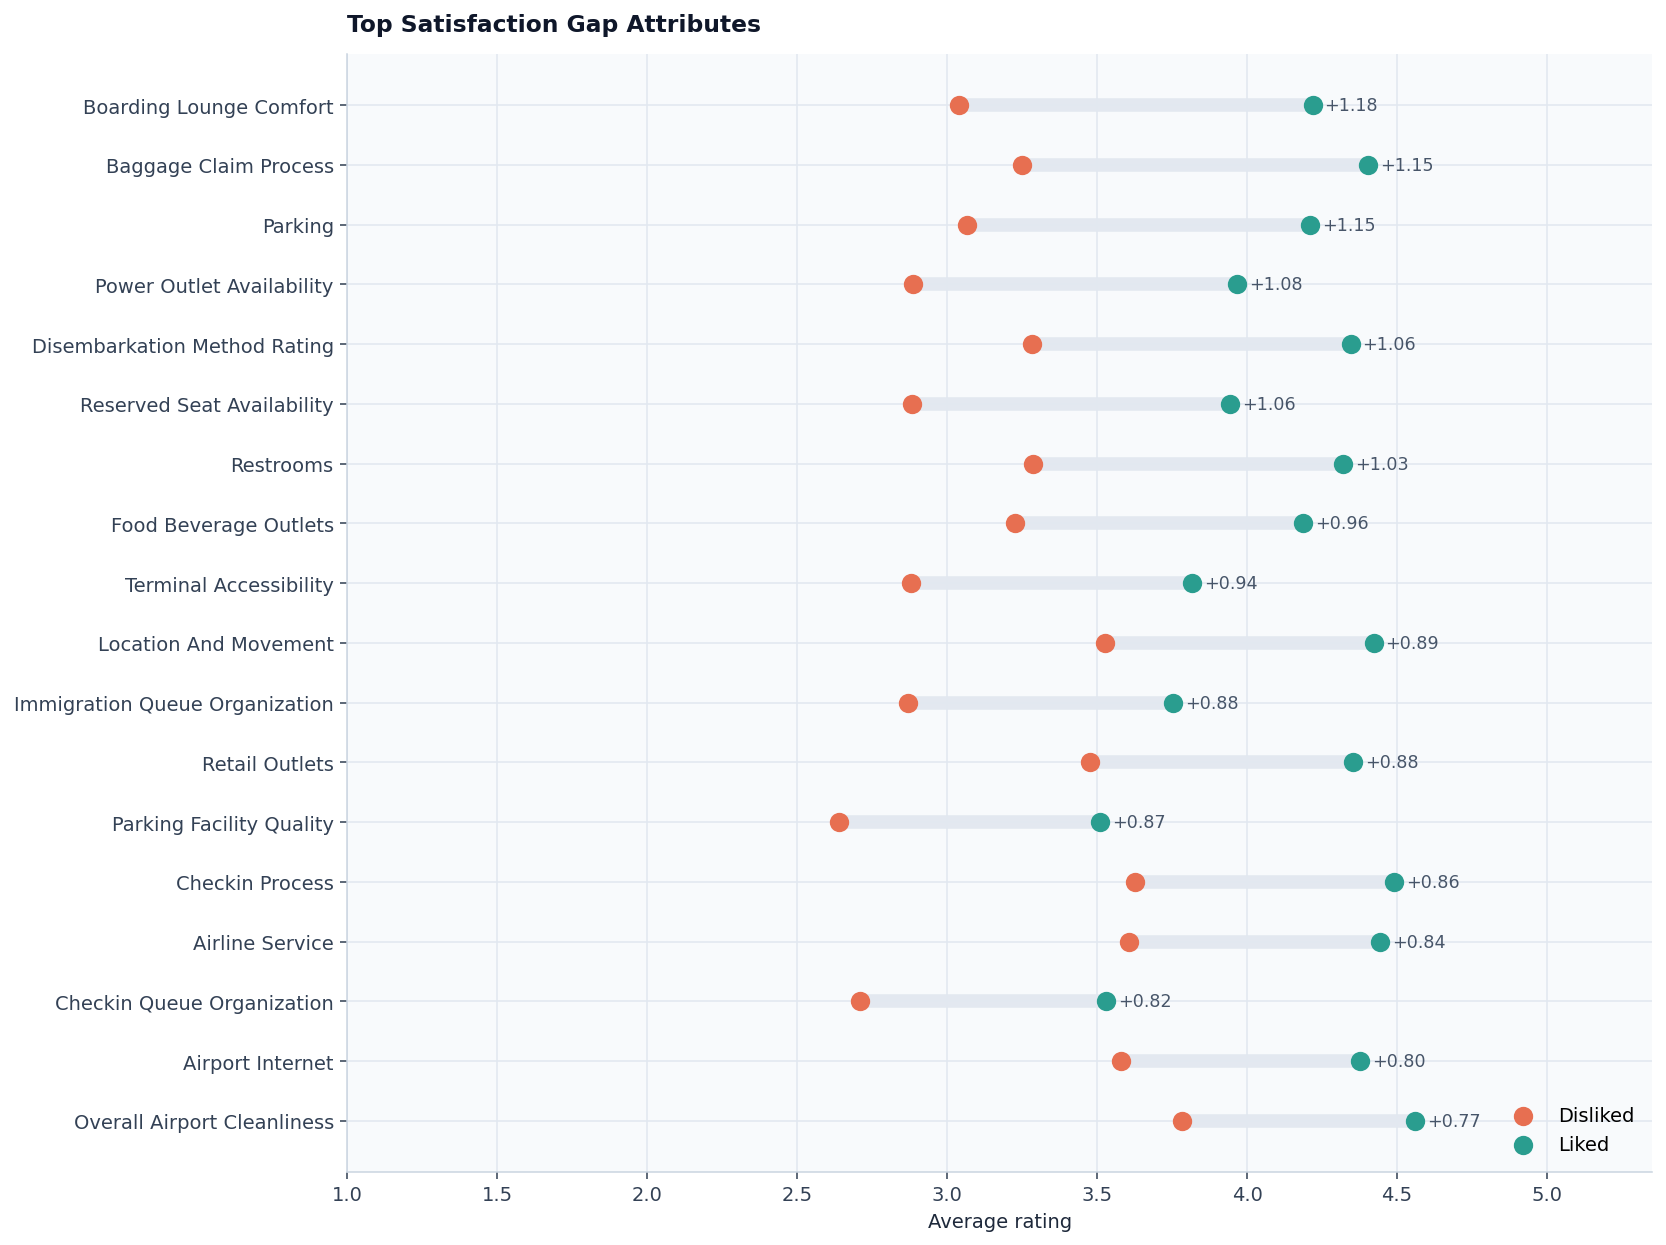

### Highest Priority Improvement Candidates

liked,Disliked,Liked,Gap,Priority Score
Boarding Lounge Comfort,3.04,4.22,1.18,2.31
Power Outlet Availability,2.89,3.97,1.08,2.29
Reserved Seat Availability,2.88,3.94,1.06,2.25
Parking,3.06,4.21,1.15,2.22
Parking Facility Quality,2.64,3.51,0.87,2.05
Baggage Claim Process,3.25,4.40,1.15,2.02
Terminal Accessibility,2.88,3.82,0.94,1.99
Parking Value For Money,2.25,2.95,0.70,1.93
Service Window Quantity,2.51,3.28,0.77,1.92
Immigration Queue Organization,2.87,3.75,0.88,1.88


In [8]:
liked_means = df.groupby("liked")[rating_cols].mean().T.rename(columns={0: "Disliked", 1: "Liked"})
liked_means["Gap"] = liked_means["Liked"] - liked_means["Disliked"]
liked_means["Disliked Mean"] = liked_means["Disliked"]
liked_means["Priority Score"] = liked_means["Gap"] * (5 - liked_means["Disliked Mean"])

top_drivers = liked_means.sort_values("Gap", ascending=False).head(18)
priority_drivers = liked_means.sort_values("Priority Score", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 9))
y_positions = np.arange(len(top_drivers))
ax.hlines(y_positions, top_drivers["Disliked"], top_drivers["Liked"], color=COLORS["light"], linewidth=7, alpha=0.95)
ax.scatter(top_drivers["Disliked"], y_positions, color=COLORS["coral"], s=80, label="Disliked", zorder=3)
ax.scatter(top_drivers["Liked"], y_positions, color=COLORS["teal"], s=80, label="Liked", zorder=3)

for y, (_, row) in zip(y_positions, top_drivers.iterrows()):
    ax.text(row["Liked"] + 0.04, y, f"+{row['Gap']:.2f}", va="center", fontsize=9, color=COLORS["slate"])

ax.set_yticks(y_positions, [wrap_label(label, 30) for label in top_drivers.index])
ax.invert_yaxis()
ax.set_xlim(1, 5.35)
ax.set_xlabel("Average rating")
ax.set_title("Top Satisfaction Gap Attributes", loc="left", weight="bold", pad=12)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()

display(Markdown("### Highest Priority Improvement Candidates"))
display(priority_drivers[["Disliked", "Liked", "Gap", "Priority Score"]].rename(index=clean_label))

## 6. Segment Patterns

Segment analysis helps translate the satisfaction outcome into passenger context. Rates below are calculated only for groups with enough records to be useful for directional reading.

,segment,value,records,liked_rate,segment_label,value_label
0,flight_type,Domestic,52008,0.50,Flight Type,Domestic
1,flight_type,International,5506,0.49,Flight Type,International
2,process,Disembarkation,24231,0.51,Process,Disembarkation
3,process,Boarding,33283,0.49,Process,Boarding
4,trip_purpose,Family,2017,0.56,Trip Purpose,Family
5,trip_purpose,Study/conference,717,0.55,Trip Purpose,Study/conference
6,trip_purpose,Leisure,15680,0.52,Trip Purpose,Leisure
7,trip_purpose,Other,1298,0.49,Trip Purpose,Other
8,trip_purpose,Leisure and business,726,0.47,Trip Purpose,Leisure and business
9,trip_purpose,Business,12037,0.44,Trip Purpose,Business


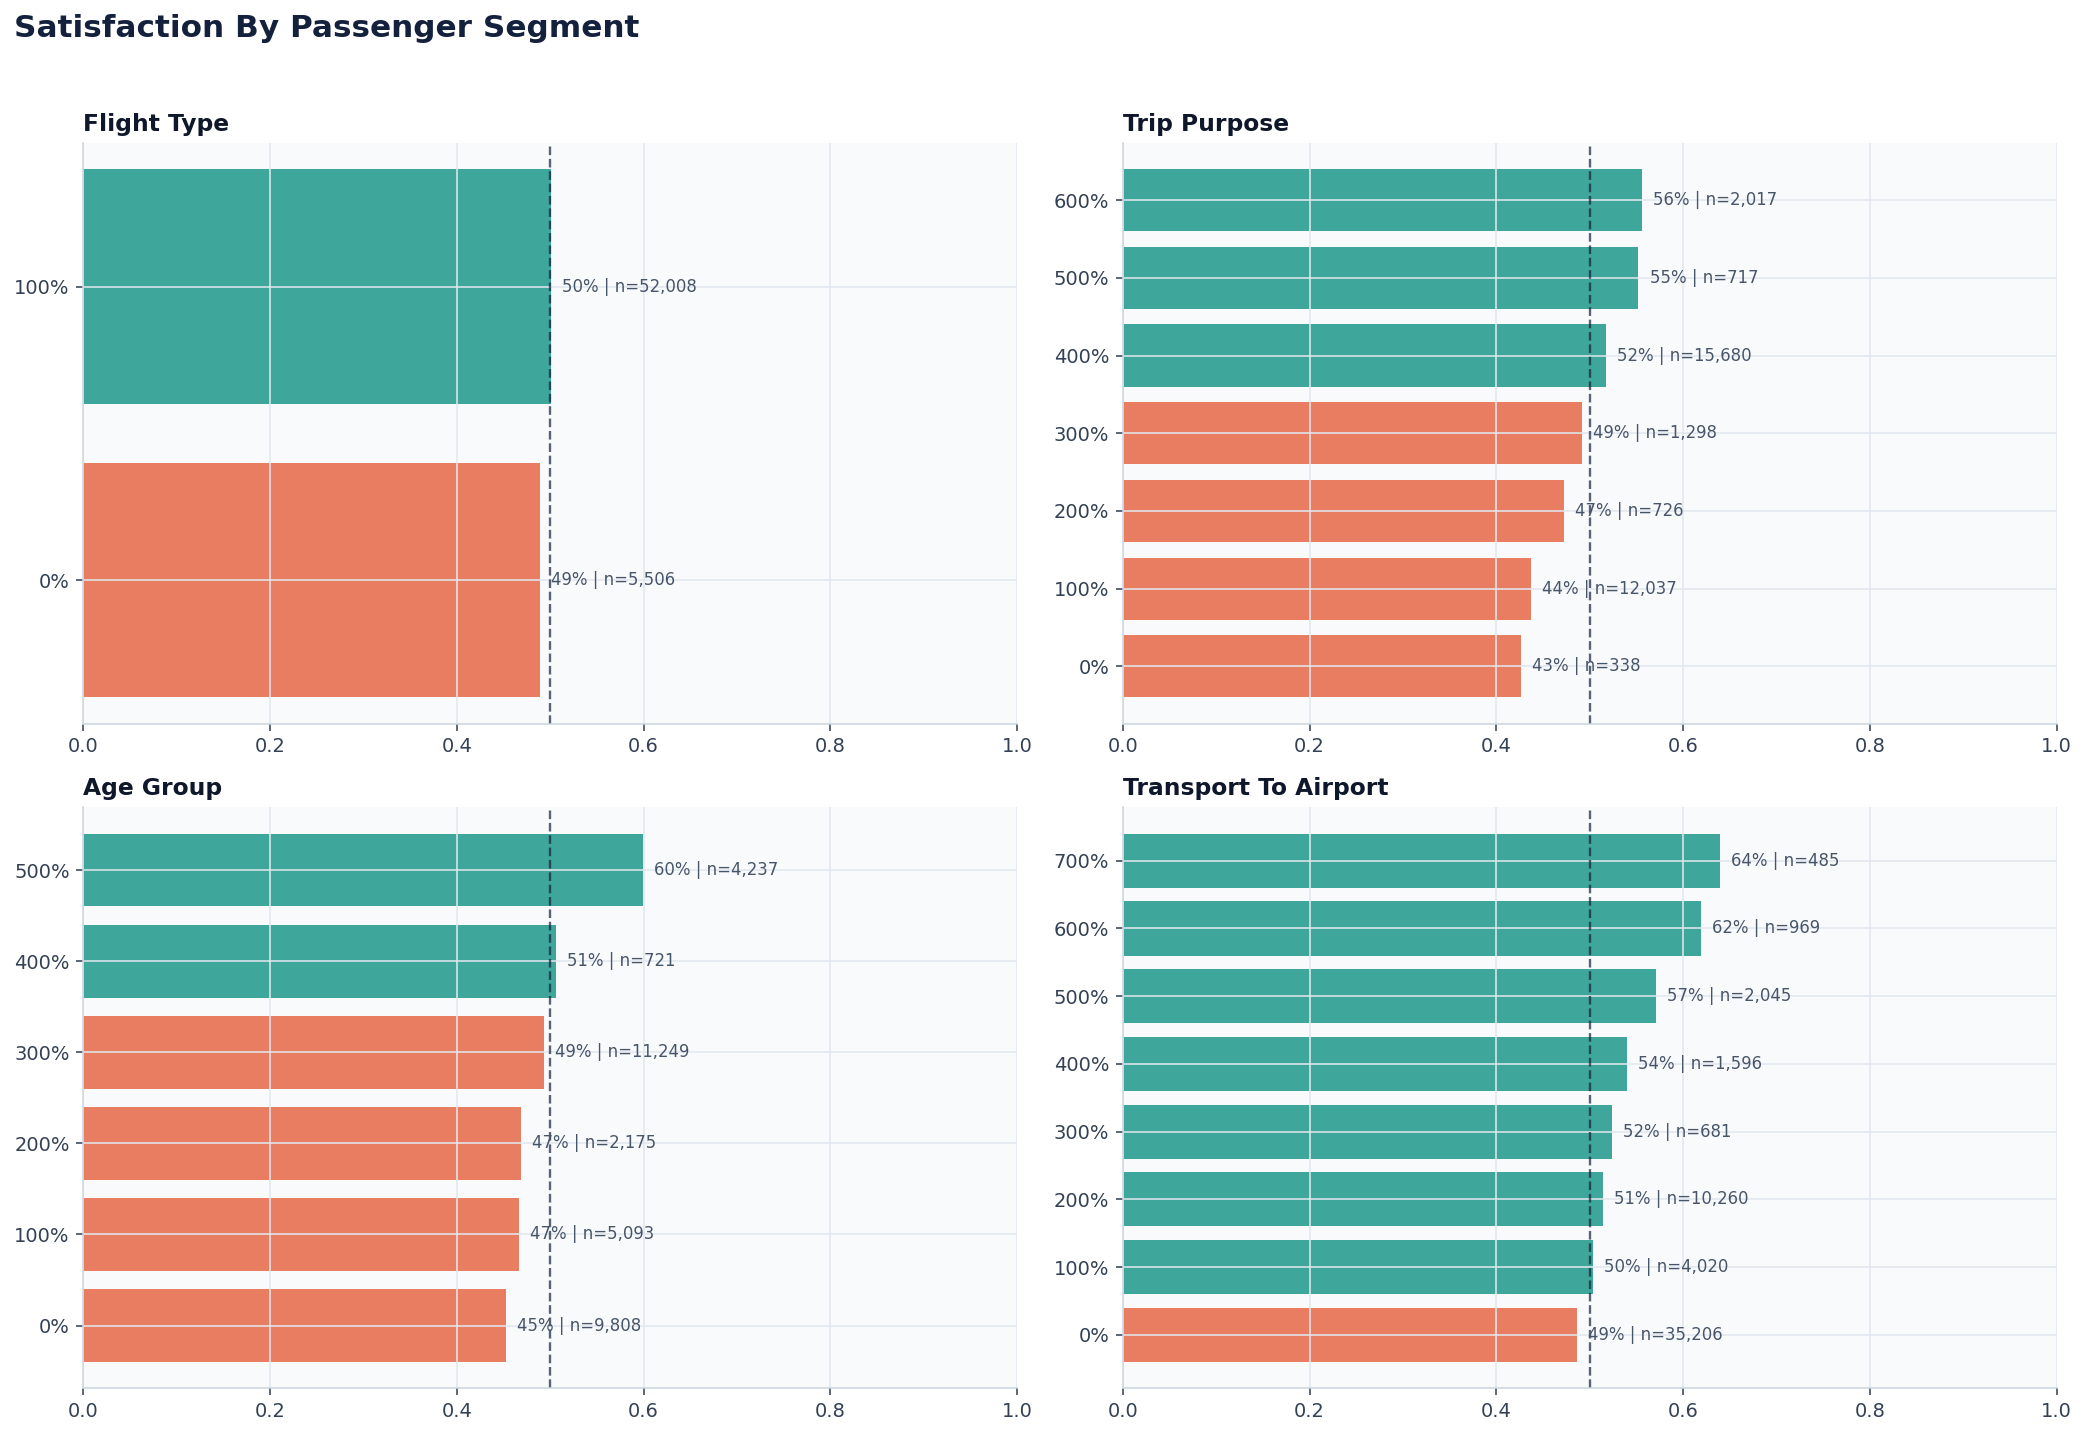

In [9]:
segment_cols = [
    "flight_type", "process", "trip_purpose", "gender", "age_group", "checkin_method", "transport_to_airport",
]
segment_frames = []
for col in segment_cols:
    if col not in df.columns:
        continue
    temp = (
        df.groupby(col)["liked"]
          .agg(records="size", liked_rate="mean")
          .query("records >= 250")
          .sort_values("liked_rate", ascending=False)
          .head(8)
          .reset_index()
    )
    temp["segment"] = col
    temp = temp.rename(columns={col: "value"})
    segment_frames.append(temp[["segment", "value", "records", "liked_rate"]])

segments = pd.concat(segment_frames, ignore_index=True)
segments["segment_label"] = segments["segment"].map(clean_label)
segments["value_label"] = segments["value"].astype(str).map(lambda text: "\n".join(wrap(text, 22)))

display(segments.head(30))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for ax, segment in zip(axes, ["flight_type", "trip_purpose", "age_group", "transport_to_airport"]):
    data = segments[segments["segment"] == segment].sort_values("liked_rate")
    if data.empty:
        ax.axis("off")
        continue
    colors = [COLORS["teal"] if value >= df["liked"].mean() else COLORS["coral"] for value in data["liked_rate"]]
    ax.barh(data["value_label"], data["liked_rate"], color=colors, alpha=0.9)
    ax.axvline(df["liked"].mean(), color=COLORS["navy"], linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_xlim(0, 1)
    ax.set_title(clean_label(segment), loc="left", weight="bold")
    percent_axis(ax)
    for idx, row in enumerate(data.itertuples()):
        ax.text(row.liked_rate + 0.012, idx, f"{row.liked_rate:.0%} | n={row.records:,}", va="center", fontsize=8.5, color=COLORS["slate"])

fig.suptitle("Satisfaction By Passenger Segment", x=0.01, y=1.02, ha="left", fontsize=16, weight="bold", color=COLORS["navy"])
fig.tight_layout()
plt.show()

## 7. Advanced Statistical Validation

This section adds statistical rigor to the exploratory findings. It uses uncertainty intervals, hypothesis tests, multiple-testing correction, and association effect sizes so the report separates visible chart patterns from statistically reliable signals.

Key methods used here:

- **Wilson confidence intervals** for liked-rate uncertainty.
- **Welch t-tests** and **Mann-Whitney U tests** for rating differences between liked and disliked trips.
- **Benjamini-Hochberg FDR correction** to reduce false discoveries across many survey attributes.
- **Cohen's d** and **Cramer's V** to focus on practical effect size, not just p-values.
- **Bootstrap confidence intervals** for journey theme gaps.

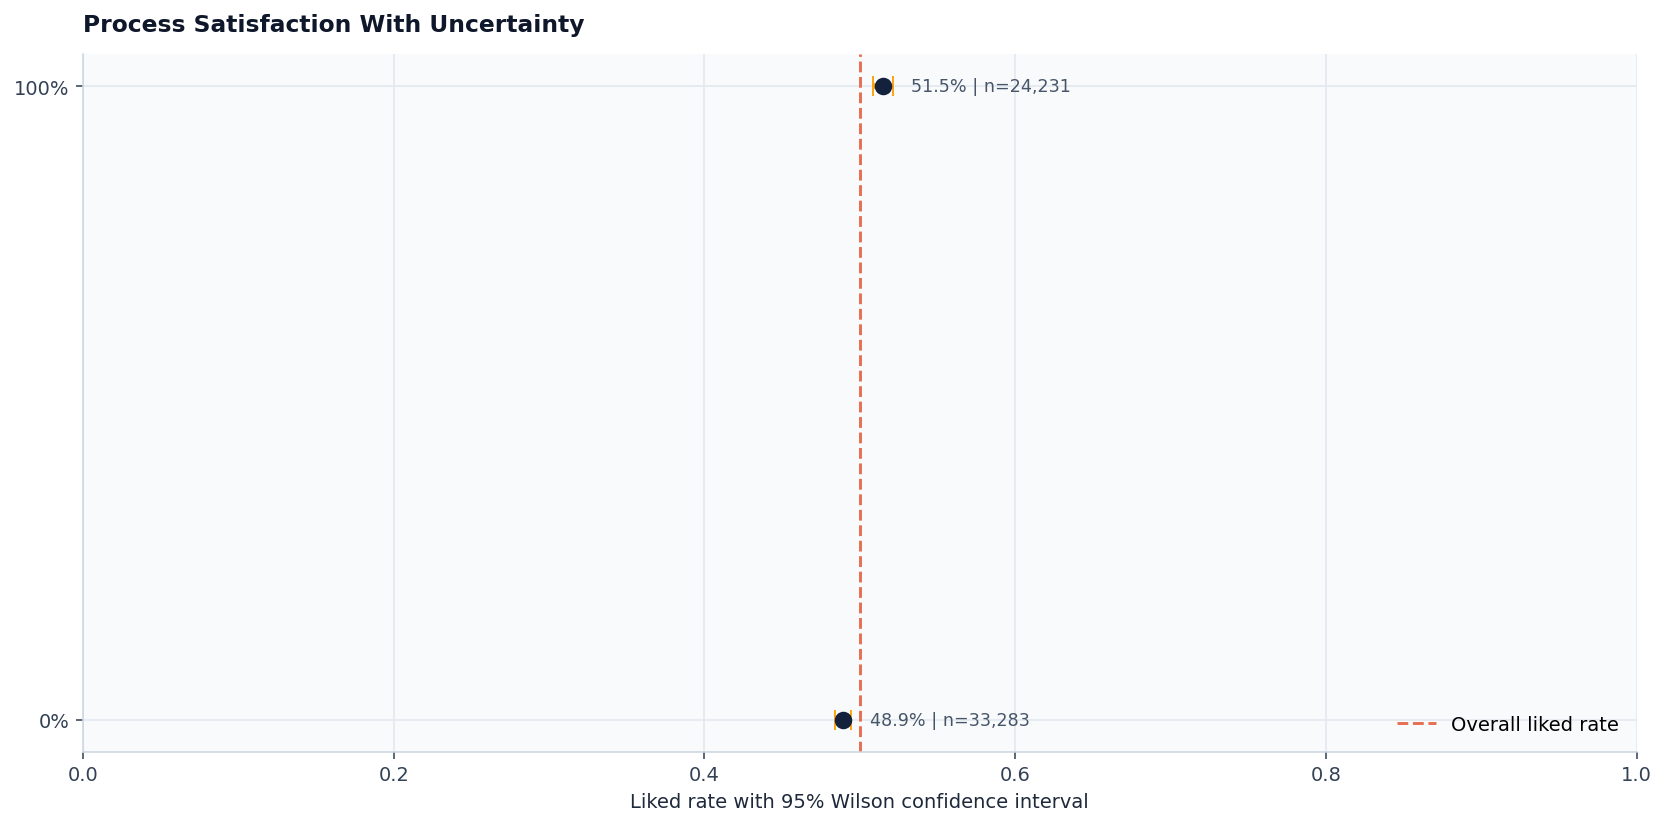

,successes,records,liked_rate,ci_low,ci_high,ci_width
process,,,,,,
Boarding,16283,33283,0.49,0.48,0.49,0.01
Disembarkation,12474,24231,0.51,0.51,0.52,0.01


In [10]:
process_ci = (
    df.groupby("process")["liked"]
      .agg(successes="sum", records="size", liked_rate="mean")
      .sort_values("liked_rate", ascending=True)
)

ci_bounds = process_ci.apply(lambda row: wilson_interval(row["successes"], row["records"]), axis=1, result_type="expand")
process_ci[["ci_low", "ci_high"]] = ci_bounds
process_ci["ci_width"] = process_ci["ci_high"] - process_ci["ci_low"]

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(process_ci))
xerr = np.vstack([
    process_ci["liked_rate"] - process_ci["ci_low"],
    process_ci["ci_high"] - process_ci["liked_rate"],
])

ax.errorbar(
    process_ci["liked_rate"],
    y_pos,
    xerr=xerr,
    fmt="o",
    color=COLORS["navy"],
    ecolor=COLORS["gold"],
    elinewidth=3,
    capsize=5,
    markersize=8,
)
ax.axvline(df["liked"].mean(), color=COLORS["coral"], linestyle="--", linewidth=1.5, label="Overall liked rate")
ax.set_yticks(y_pos, [wrap_label(label, 28) for label in process_ci.index])
ax.set_xlim(0, 1)
ax.set_xlabel("Liked rate with 95% Wilson confidence interval")
ax.set_title("Process Satisfaction With Uncertainty", loc="left", weight="bold", pad=12)
percent_axis(ax)
ax.legend(frameon=False, loc="lower right")

for idx, row in enumerate(process_ci.itertuples()):
    ax.text(row.ci_high + 0.012, idx, f"{row.liked_rate:.1%} | n={row.records:,}", va="center", fontsize=9, color=COLORS["slate"])

fig.tight_layout()
plt.show()

display(process_ci.rename(index=clean_label))

### Rating Differences: Statistical And Practical Significance

,attribute,disliked_mean,liked_mean,mean_gap,cohens_d,welch_q,mannwhitney_q,statistically_reliable,practical_signal
41,Boarding Lounge Comfort,3.04,4.22,1.18,1.31,0.00,0.00,True,True
32,Parking,3.06,4.21,1.15,1.13,0.00,0.00,True,True
55,Baggage Claim Process,3.25,4.40,1.15,1.11,0.00,0.00,True,True
54,Overall Airport Cleanliness,3.78,4.56,0.77,1.07,0.00,0.00,True,True
50,Restrooms,3.29,4.32,1.03,1.03,0.00,0.00,True,True
0,Disembarkation Method Rating,3.28,4.35,1.06,1.01,0.00,0.00,True,True
37,Location And Movement,3.53,4.42,0.89,1.00,0.00,0.00,True,True
46,Power Outlet Availability,2.89,3.97,1.08,0.97,0.00,0.00,True,True
24,Food Beverage Outlets,3.23,4.19,0.96,0.96,0.00,0.00,True,True
28,Retail Outlets,3.48,4.35,0.88,0.95,0.00,0.00,True,True


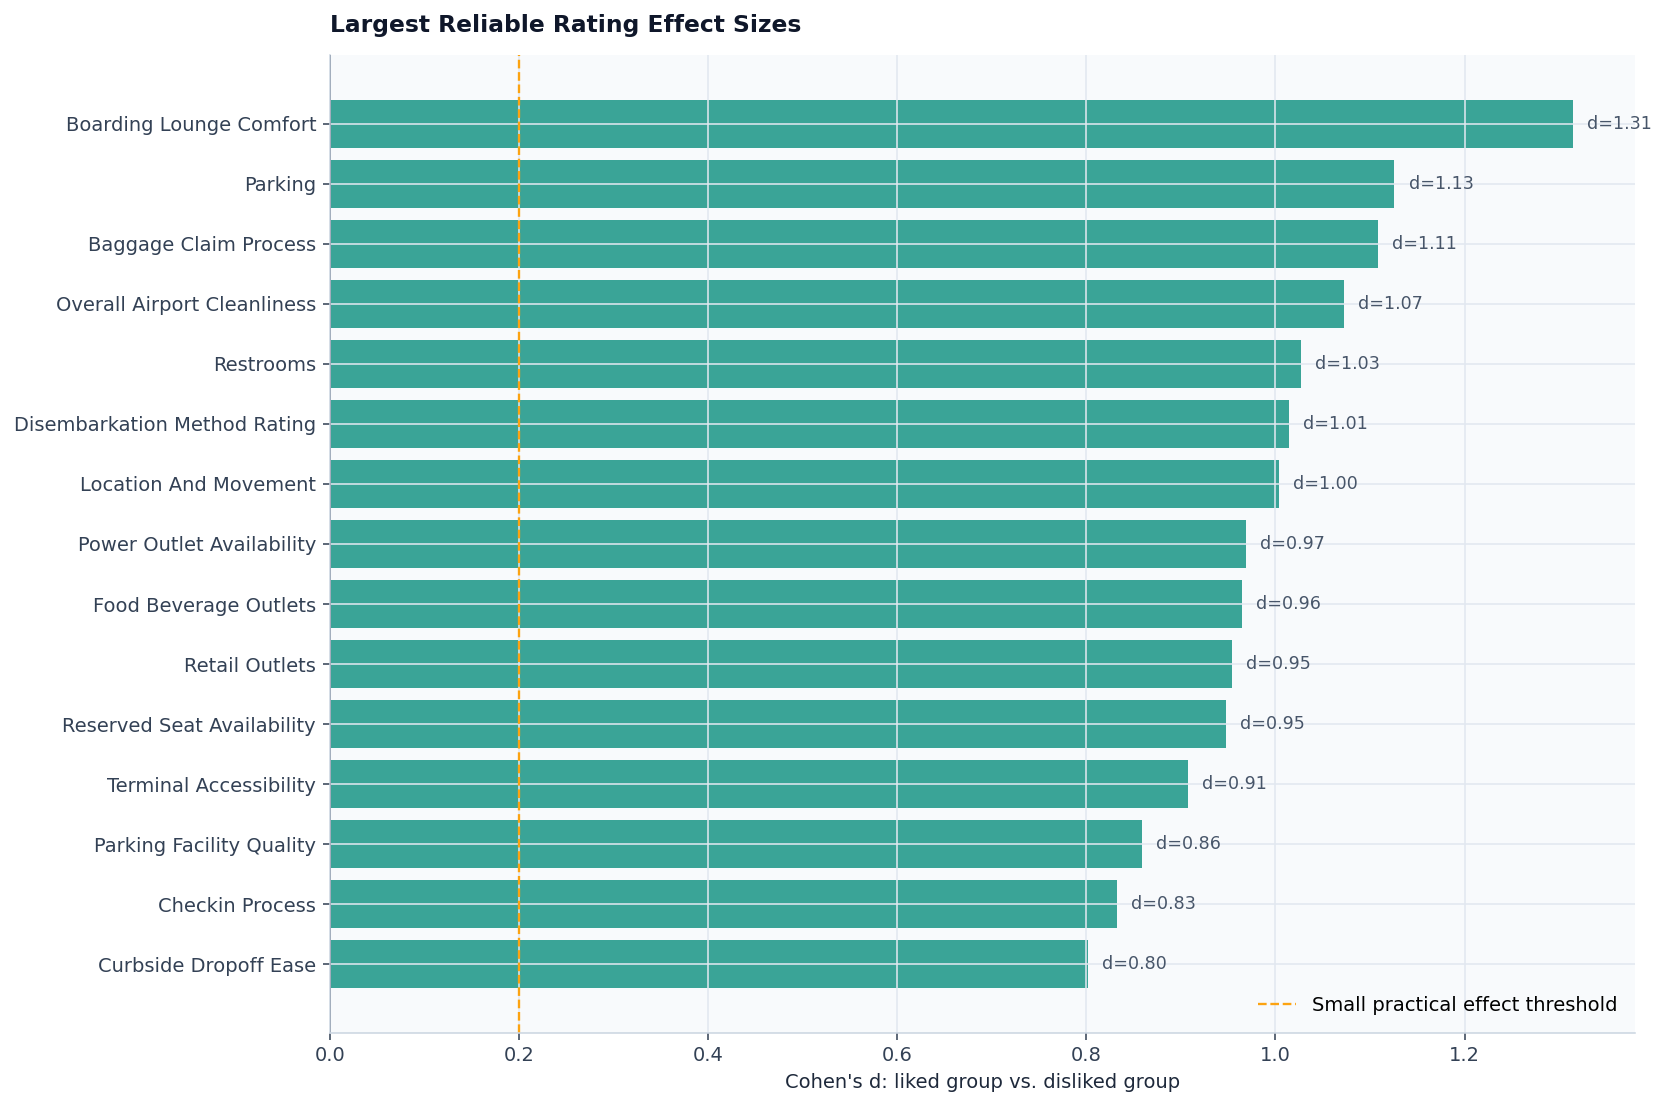

In [11]:
rating_test_rows = []
for col in rating_cols:
    disliked = df.loc[df["liked"] == 0, col].dropna()
    liked = df.loc[df["liked"] == 1, col].dropna()
    if len(disliked) < 30 or len(liked) < 30:
        continue

    welch = stats.ttest_ind(liked, disliked, equal_var=False, nan_policy="omit")
    mann = stats.mannwhitneyu(liked, disliked, alternative="two-sided", method="asymptotic")
    rating_test_rows.append({
        "attribute": col,
        "disliked_mean": disliked.mean(),
        "liked_mean": liked.mean(),
        "mean_gap": liked.mean() - disliked.mean(),
        "cohens_d": cohen_d(liked, disliked),
        "welch_p": welch.pvalue,
        "mannwhitney_p": mann.pvalue,
        "disliked_n": len(disliked),
        "liked_n": len(liked),
    })

rating_tests = pd.DataFrame(rating_test_rows)
rating_tests["welch_q"] = benjamini_hochberg(rating_tests["welch_p"])
rating_tests["mannwhitney_q"] = benjamini_hochberg(rating_tests["mannwhitney_p"])
rating_tests["statistically_reliable"] = rating_tests["welch_q"].lt(0.05) & rating_tests["mannwhitney_q"].lt(0.05)
rating_tests["practical_signal"] = rating_tests["cohens_d"].abs().ge(0.20)

stat_driver_table = (
    rating_tests.sort_values(["practical_signal", "cohens_d"], ascending=[False, False])
                .head(18)
                .assign(attribute=lambda data: data["attribute"].map(clean_label))
)

display(Markdown("### Rating Differences: Statistical And Practical Significance"))
display(stat_driver_table[[
    "attribute", "disliked_mean", "liked_mean", "mean_gap", "cohens_d",
    "welch_q", "mannwhitney_q", "statistically_reliable", "practical_signal",
]])

plot_data = rating_tests.sort_values("cohens_d", ascending=False).head(15).sort_values("cohens_d")
fig, ax = plt.subplots(figsize=(12, 8))
colors = [COLORS["teal"] if reliable else COLORS["slate"] for reliable in plot_data["statistically_reliable"]]
ax.barh([wrap_label(label, 32) for label in plot_data["attribute"]], plot_data["cohens_d"], color=colors, alpha=0.92)
ax.axvline(0.2, color=COLORS["gold"], linestyle="--", linewidth=1.2, label="Small practical effect threshold")
ax.axvline(0, color=COLORS["navy"], linewidth=1)
ax.set_xlabel("Cohen's d: liked group vs. disliked group")
ax.set_title("Largest Reliable Rating Effect Sizes", loc="left", weight="bold", pad=12)
ax.legend(frameon=False, loc="lower right")
for idx, row in enumerate(plot_data.itertuples()):
    ax.text(row.cohens_d + 0.015, idx, f"d={row.cohens_d:.2f}", va="center", fontsize=9, color=COLORS["slate"])
fig.tight_layout()
plt.show()

C:\Users\hieum\AppData\Local\Temp\ipykernel_35348\2885023556.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


### Categorical Association With Satisfaction

,feature,levels,records,cramers_v,q_value,statistically_reliable
21,Trips Last 12 Months,6,57514,0.16,0.00,True
17,Household Income,9,57514,0.12,0.00,True
16,Education,8,57514,0.11,0.00,True
22,Used Airport Before Last 12 Months,4,57514,0.10,0.00,True
12,Checkin Method,7,57514,0.08,0.00,True
3,Connection,3,57514,0.08,0.00,True
15,Age Group,7,57514,0.07,0.00,True
20,Trip Purpose,17,57514,0.07,0.00,True
6,Transport To Airport,17,57514,0.06,0.00,True
5,Ticket Purchase Channel,13,57514,0.04,0.00,True


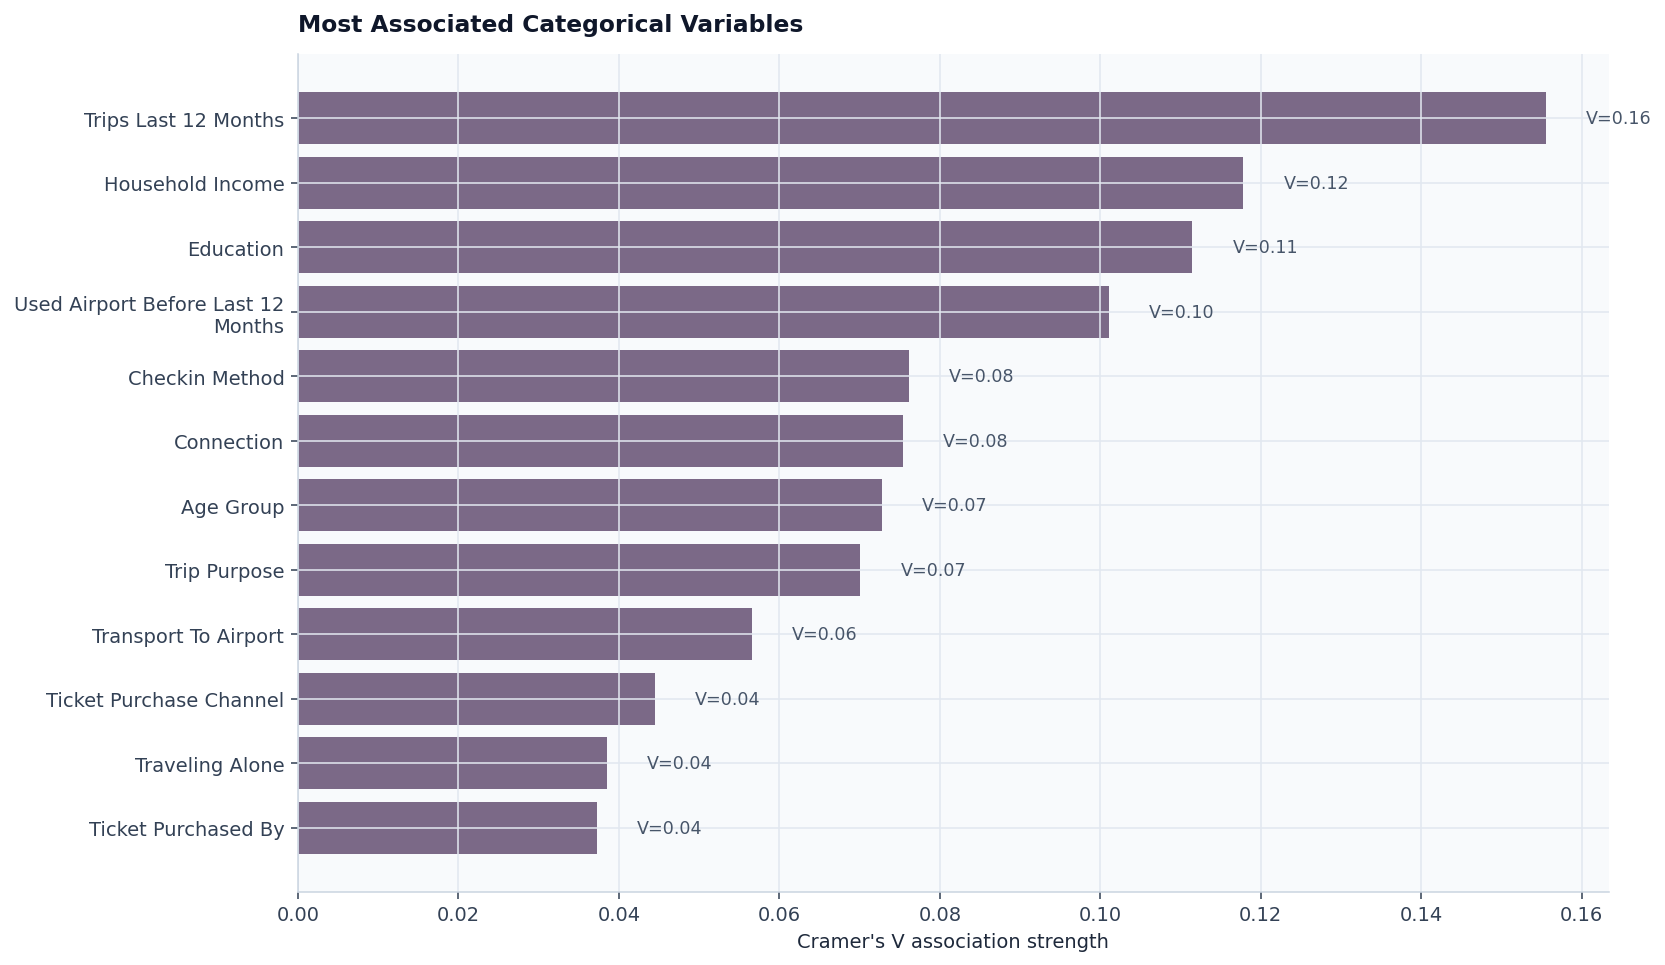

In [12]:
categorical_cols = []
for col in df.select_dtypes(include="object").columns:
    unique_count = df[col].nunique(dropna=True)
    if 2 <= unique_count <= 35:
        categorical_cols.append(col)

categorical_rows = []
for col in categorical_cols:
    temp = df[[col, "liked"]].copy()
    temp[col] = temp[col].fillna("Missing")
    contingency = pd.crosstab(temp[col], temp["liked"])
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    categorical_rows.append({
        "feature": col,
        "levels": contingency.shape[0],
        "records": int(contingency.to_numpy().sum()),
        "chi2": chi2,
        "dof": dof,
        "p_value": p_value,
        "cramers_v": cramers_v(contingency),
    })

categorical_tests = pd.DataFrame(categorical_rows)
categorical_tests["q_value"] = benjamini_hochberg(categorical_tests["p_value"])
categorical_tests["statistically_reliable"] = categorical_tests["q_value"].lt(0.05)

cat_display = (
    categorical_tests.sort_values("cramers_v", ascending=False)
                     .head(15)
                     .assign(feature=lambda data: data["feature"].map(clean_label))
)

display(Markdown("### Categorical Association With Satisfaction"))
display(cat_display[["feature", "levels", "records", "cramers_v", "q_value", "statistically_reliable"]])

plot_data = categorical_tests.sort_values("cramers_v", ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(12, 7))
colors = [COLORS["violet"] if reliable else COLORS["slate"] for reliable in plot_data["statistically_reliable"]]
ax.barh([wrap_label(label, 30) for label in plot_data["feature"]], plot_data["cramers_v"], color=colors, alpha=0.9)
ax.set_xlabel("Cramer's V association strength")
ax.set_title("Most Associated Categorical Variables", loc="left", weight="bold", pad=12)
for idx, row in enumerate(plot_data.itertuples()):
    ax.text(row.cramers_v + 0.005, idx, f"V={row.cramers_v:.2f}", va="center", fontsize=9, color=COLORS["slate"])
fig.tight_layout()
plt.show()

### Bootstrap Confidence Intervals For Theme Gaps

,theme,observed_gap,ci_low,ci_high,liked_n,disliked_n
2,Security & Border,0.51,0.49,0.52,13298,12367
1,Check-In & Airline,0.52,0.50,0.54,10431,11021
5,Digital Experience,0.72,0.68,0.76,4266,3885
0,Access & Parking,0.74,0.71,0.76,11621,10621
6,Cleanliness & Restrooms,0.89,0.87,0.91,16269,16971
7,Baggage & Arrival,0.93,0.91,0.96,8746,8244
4,Wayfinding & Comfort,0.95,0.93,0.96,28693,28693
3,Commercial Offer,1.01,0.98,1.04,7742,9818


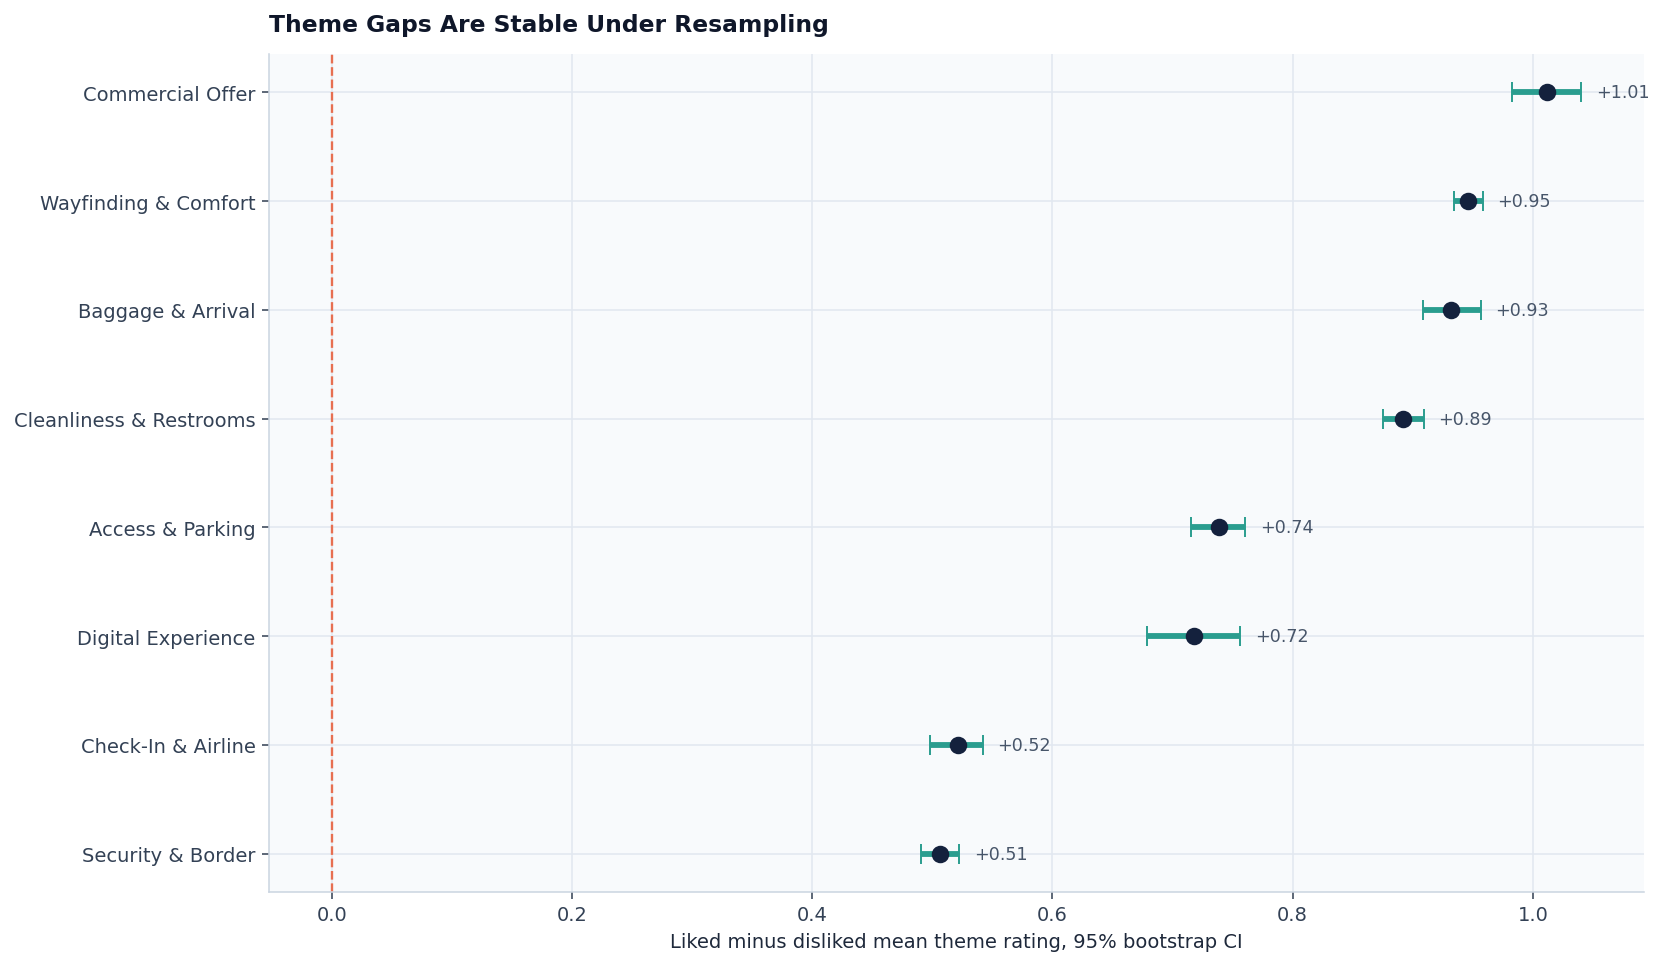

In [13]:
rng = np.random.default_rng(42)
bootstrap_rows = []
labels = theme_scores["liked"].to_numpy()

for theme in theme_map:
    values = theme_scores[theme]
    liked_values = values[labels == 1].dropna().to_numpy()
    disliked_values = values[labels == 0].dropna().to_numpy()
    if len(liked_values) < 50 or len(disliked_values) < 50:
        continue
    observed_gap = liked_values.mean() - disliked_values.mean()
    boot_gaps = []
    for _ in range(600):
        liked_sample = rng.choice(liked_values, size=len(liked_values), replace=True)
        disliked_sample = rng.choice(disliked_values, size=len(disliked_values), replace=True)
        boot_gaps.append(liked_sample.mean() - disliked_sample.mean())
    ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])
    bootstrap_rows.append({
        "theme": theme,
        "observed_gap": observed_gap,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "liked_n": len(liked_values),
        "disliked_n": len(disliked_values),
    })

bootstrap_theme_gaps = pd.DataFrame(bootstrap_rows).sort_values("observed_gap")

display(Markdown("### Bootstrap Confidence Intervals For Theme Gaps"))
display(bootstrap_theme_gaps.assign(theme=lambda data: data["theme"].map(clean_label)))

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(bootstrap_theme_gaps))
xerr = np.vstack([
    bootstrap_theme_gaps["observed_gap"] - bootstrap_theme_gaps["ci_low"],
    bootstrap_theme_gaps["ci_high"] - bootstrap_theme_gaps["observed_gap"],
])
ax.errorbar(
    bootstrap_theme_gaps["observed_gap"],
    y_pos,
    xerr=xerr,
    fmt="o",
    color=COLORS["navy"],
    ecolor=COLORS["teal"],
    elinewidth=3,
    capsize=5,
    markersize=8,
)
ax.axvline(0, color=COLORS["coral"], linestyle="--", linewidth=1.2)
ax.set_yticks(y_pos, [wrap_label(label, 28) for label in bootstrap_theme_gaps["theme"]])
ax.set_xlabel("Liked minus disliked mean theme rating, 95% bootstrap CI")
ax.set_title("Theme Gaps Are Stable Under Resampling", loc="left", weight="bold", pad=12)
for idx, row in enumerate(bootstrap_theme_gaps.itertuples()):
    ax.text(row.ci_high + 0.012, idx, f"{row.observed_gap:+.2f}", va="center", fontsize=9, color=COLORS["slate"])
fig.tight_layout()
plt.show()

## 8. Compact Predictive Check

A logistic regression model using only detected rating attributes is used as a sanity check. The goal is not to productionize a model; it is to validate which ratings carry the clearest relationship with the satisfaction outcome.

,metric,value
0,Accuracy,80.65%
1,ROC AUC,0.879
2,Training rows,"43,135"
3,Test rows,"14,379"
4,Rating features,60


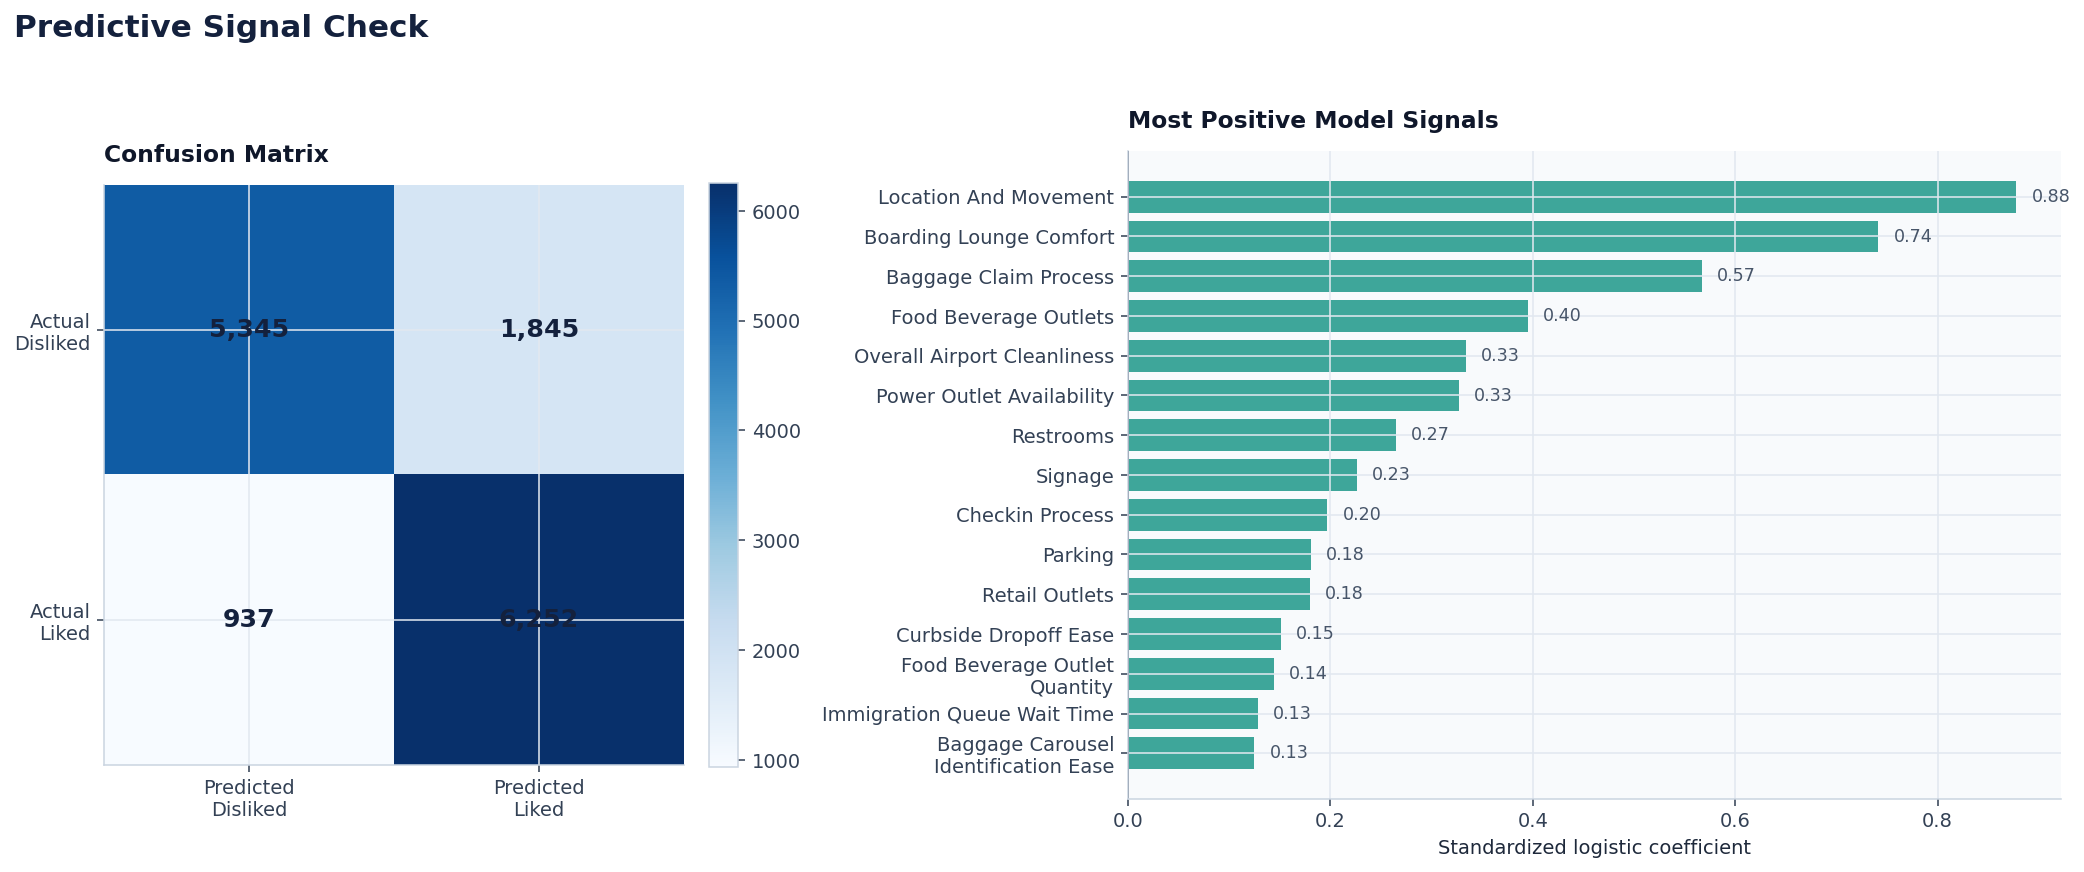

In [14]:
X = df[rating_cols]
y = df["liked"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

model.fit(X_train, y_train)
probabilities = model.predict_proba(X_test)[:, 1]
predictions = (probabilities >= 0.5).astype(int)

metrics = pd.DataFrame({
    "metric": ["Accuracy", "ROC AUC", "Training rows", "Test rows", "Rating features"],
    "value": [
        f"{accuracy_score(y_test, predictions):.2%}",
        f"{roc_auc_score(y_test, probabilities):.3f}",
        f"{len(X_train):,}",
        f"{len(X_test):,}",
        f"{len(rating_cols):,}",
    ],
})

display(metrics)

coef = pd.Series(model.named_steps["classifier"].coef_[0], index=rating_cols, name="coefficient")
coef_top = coef.sort_values(ascending=False).head(15)
cm = confusion_matrix(y_test, predictions)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [0.85, 1.25]})

im = ax1.imshow(cm, cmap="Blues")
ax1.set_xticks([0, 1], ["Predicted\nDisliked", "Predicted\nLiked"])
ax1.set_yticks([0, 1], ["Actual\nDisliked", "Actual\nLiked"])
ax1.set_title("Confusion Matrix", loc="left", weight="bold", pad=12)
for row in range(2):
    for col in range(2):
        ax1.text(col, row, f"{cm[row, col]:,}", ha="center", va="center", fontsize=13, weight="bold", color=COLORS["navy"])
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

ax2.barh([wrap_label(label, 27) for label in coef_top.index[::-1]], coef_top.values[::-1], color=COLORS["teal"], alpha=0.9)
ax2.axvline(0, color=COLORS["navy"], linewidth=1)
ax2.set_xlabel("Standardized logistic coefficient")
ax2.set_title("Most Positive Model Signals", loc="left", weight="bold", pad=12)
for idx, value in enumerate(coef_top.values[::-1]):
    ax2.text(value + 0.015, idx, f"{value:.2f}", va="center", fontsize=9, color=COLORS["slate"])

fig.suptitle("Predictive Signal Check", x=0.01, y=1.03, ha="left", fontsize=16, weight="bold", color=COLORS["navy"])
fig.tight_layout()
plt.show()

## 9. Recommendations

The recommendation table combines the observed liked/disliked gap with the disliked-group baseline. The higher the priority score, the more the attribute appears both differentiated and underperforming among disliked trips.

In [15]:
def action_hint(feature: str) -> str:
    text = feature.lower()
    if "queue" in text or "wait" in text or "time" in text:
        return "Reduce perceived waiting, improve queue visibility, and communicate expected timing."
    if "staff" in text or "courtesy" in text or "service" in text:
        return "Standardize service behaviors and reinforce frontline recovery moments."
    if "internet" in text or "network" in text or "power" in text:
        return "Improve digital reliability and make connectivity resources easier to find."
    if "clean" in text or "restroom" in text:
        return "Increase inspection cadence and prioritize cleanliness at peak passenger flows."
    if "signage" in text or "information" in text or "accessibility" in text:
        return "Simplify wayfinding, improve information placement, and test accessibility paths."
    if "parking" in text or "dropoff" in text or "transport" in text:
        return "Clarify access options and reduce friction at arrival and parking touchpoints."
    if "baggage" in text or "carousel" in text:
        return "Improve baggage status visibility and reduce uncertainty at claim areas."
    if "food" in text or "retail" in text or "price" in text:
        return "Review assortment, value perception, and availability across passenger dwell times."
    return "Investigate operational root causes and test targeted service improvements."

recommendations = priority_drivers.copy()
recommendations["Attribute"] = recommendations.index.map(clean_label)
recommendations["Recommended Action"] = recommendations.index.map(action_hint)
recommendations = recommendations[["Attribute", "Disliked", "Liked", "Gap", "Priority Score", "Recommended Action"]]

display(recommendations.reset_index(drop=True))

liked,Attribute,Disliked,Liked,Gap,Priority Score,Recommended Action
0,Boarding Lounge Comfort,3.04,4.22,1.18,2.31,Investigate operational root causes and test t...
1,Power Outlet Availability,2.89,3.97,1.08,2.29,Improve digital reliability and make connectiv...
2,Reserved Seat Availability,2.88,3.94,1.06,2.25,Investigate operational root causes and test t...
3,Parking,3.06,4.21,1.15,2.22,Clarify access options and reduce friction at ...
4,Parking Facility Quality,2.64,3.51,0.87,2.05,Clarify access options and reduce friction at ...
5,Baggage Claim Process,3.25,4.40,1.15,2.02,Improve baggage status visibility and reduce u...
6,Terminal Accessibility,2.88,3.82,0.94,1.99,"Simplify wayfinding, improve information place..."
7,Parking Value For Money,2.25,2.95,0.70,1.93,Clarify access options and reduce friction at ...
8,Service Window Quantity,2.51,3.28,0.77,1.92,Standardize service behaviors and reinforce fr...
9,Immigration Queue Organization,2.87,3.75,0.88,1.88,"Reduce perceived waiting, improve queue visibi..."


## 10. Closing Note

This notebook is designed to be version-controlled and rendered directly on GitHub. The visuals are static Matplotlib outputs so the report remains readable without requiring interactive extensions.

**Created by Hieu Nguyen**